In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://github.com/Explore-AI/Public-Data/blob/master/house_price_by_area.csv?raw=true")
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


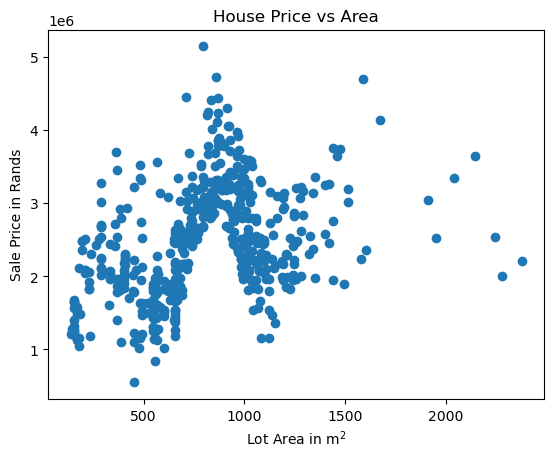

In [3]:
X = df["LotArea"]
y = df["SalePrice"]

plt.scatter(X, y)
plt.title("House Price vs Area")
plt.xlabel("Lot Area in m$^2$")
plt.ylabel("Sale Price in Rands")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X.values.reshape(-1, 1), y, test_size=0.2, random_state=42)

In [6]:
from sklearn.tree import DecisionTreeRegressor

In [7]:
regr_tree = DecisionTreeRegressor(max_depth=2, random_state=42)

In [8]:
regr_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

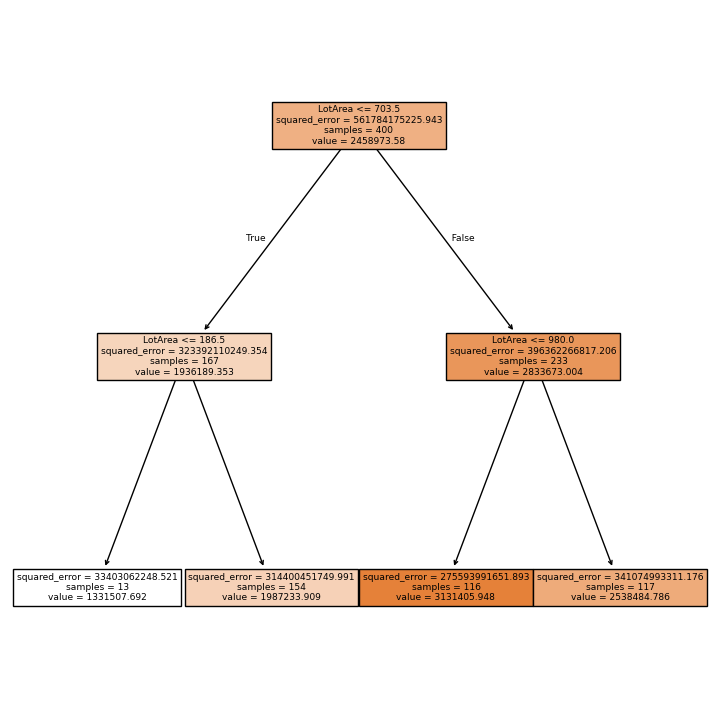

In [10]:
from sklearn.tree import plot_tree
plt.figure(figsize=(9,9))
_ = plot_tree(regr_tree, feature_names=['LotArea'], filled=True)

In [13]:
from sklearn.metrics import mean_squared_error
y_pred = regr_tree.predict(X_test)
MSE = mean_squared_error(y_pred, y_test)
print("MSE is:", MSE)
print("RMSE is:", np.sqrt(MSE))

MSE is: 391341934124.0589
RMSE is: 625573.2843752672


In [14]:
x_domain = np.linspace(min(X), max(X), 100)[:, np.newaxis]

In [15]:
y_predictions = regr_tree.predict(x_domain)

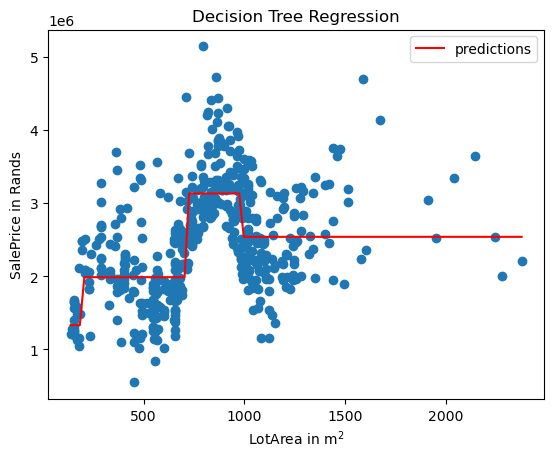

In [17]:
plt.figure()
plt.scatter(X, y)
plt.plot(x_domain, y_predictions, color="red", label='predictions')
plt.xlabel("LotArea in m$^2$")
plt.ylabel("SalePrice in Rands")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()